# Experiment No. 6

# Decision Tree and K-Nearest Neighbour (KNN) for Classification

## Aim

To understand and implement the working of Decision Tree and K-Nearest Neighbour (KNN) algorithms for classification tasks using Python and evaluate their performance on the Iris dataset.



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

# Load Dataset

In [3]:
url = "https://raw.githubusercontent.com/uiuc-cse/data-fa14/gh-pages/data/iris.csv"

data = pd.read_csv(url)

data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
print("Shape of dataset:", data.shape)
print("\nColumns:")
print(data.columns.tolist())

print("\nDataset Information:")
data.info()

Shape of dataset: (150, 5)

Columns:
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [5]:
data.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
print(data.isnull().sum())

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


# Class Distribution

In [7]:
print(data["species"].value_counts())

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


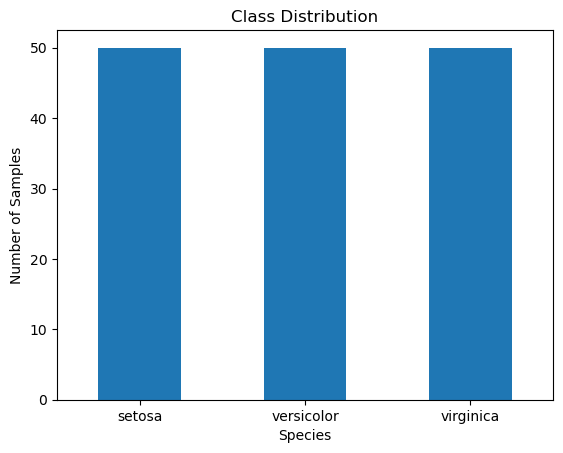

In [8]:
data["species"].value_counts().plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Species")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.show()

# Define Features and Target

In [9]:
X = data.drop("species", axis=1)
y = data["species"]

print("Features:")
print(X.columns.tolist())

print("\nTarget Classes:")
print(y.unique())

Features:
['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

Target Classes:
['setosa' 'versicolor' 'virginica']


# Split Dataset

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


## Feature Scaling

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

X_train_scaled.head()

,sepal_length,sepal_width,petal_length,petal_width
8,-1.721568,-0.324840,-1.347036,-1.320168
106,-1.124492,-1.226129,0.414290,0.651867
76,1.144395,-0.550162,0.584741,0.257460
9,-1.124492,0.125805,-1.290219,-1.451638
89,-0.408002,-1.226129,0.130206,0.125991


## Decision Tree Classifier

In [12]:
dt_model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

## Decision Tree Prediction

In [14]:
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Predictions:")
print(y_pred_dt)

Decision Tree Predictions:
['setosa' 'virginica' 'versicolor' 'versicolor' 'setosa' 'versicolor'
 'setosa' 'setosa' 'virginica' 'versicolor' 'virginica' 'virginica'
 'virginica' 'versicolor' 'setosa' 'setosa' 'setosa' 'versicolor'
 'versicolor' 'virginica' 'setosa' 'virginica' 'versicolor' 'versicolor'
 'virginica' 'virginica' 'versicolor' 'setosa' 'virginica' 'setosa']


## Decision Tree Evaluation

In [16]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt, average="weighted")
dt_recall = recall_score(y_test, y_pred_dt, average="weighted")
dt_f1 = f1_score(y_test, y_pred_dt, average="weighted")

print("Decision Tree Results")
print("---------------------")
print("Accuracy :", round(dt_accuracy * 100, 2), "%")
print("Precision:", round(dt_precision * 100, 2), "%")
print("Recall   :", round(dt_recall * 100, 2), "%")
print("F1-Score :", round(dt_f1 * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Results
---------------------
Accuracy : 93.33 %
Precision: 93.33 %
Recall   : 93.33 %
F1-Score : 93.33 %

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [17]:
dt_cm = confusion_matrix(y_test, y_pred_dt)

print(dt_cm)

[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


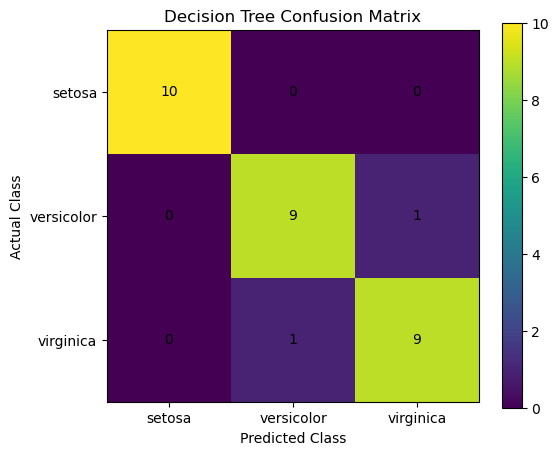

In [18]:
plt.figure(figsize=(6, 5))

plt.imshow(dt_cm)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    range(len(y.unique())),
    y.unique()
)

plt.yticks(
    range(len(y.unique())),
    y.unique()
)

for i in range(dt_cm.shape[0]):
    for j in range(dt_cm.shape[1]):
        plt.text(j, i, dt_cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

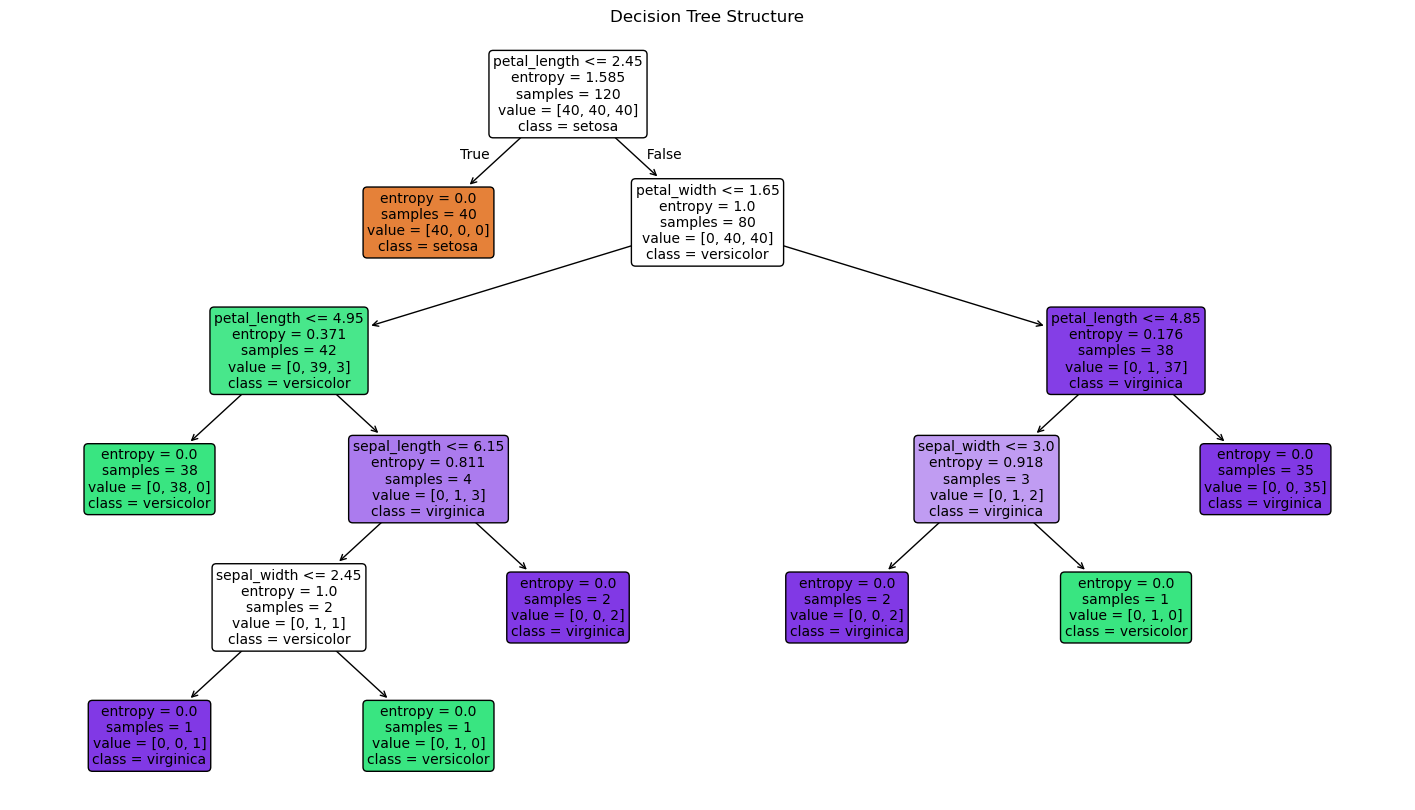

In [19]:
plt.figure(figsize=(18, 10))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=dt_model.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree Structure")
plt.show()

## Decision Tree Feature Importance

In [21]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
2,petal_length,0.664888
3,petal_width,0.303565
1,sepal_width,0.025000
0,sepal_length,0.006546


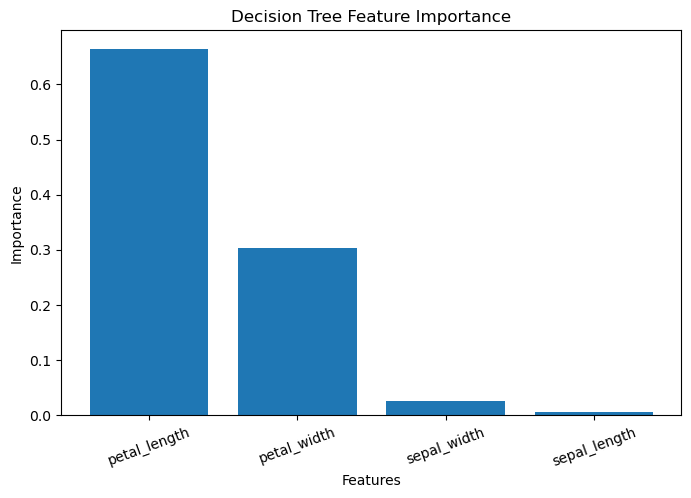

In [22]:
plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Decision Tree Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=20)
plt.show()

## K-Nearest Neighbour Classifier

In [24]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [25]:
y_pred_knn = knn_model.predict(X_test_scaled)

print("KNN Predictions:")
print(y_pred_knn)

KNN Predictions:
['setosa' 'virginica' 'versicolor' 'versicolor' 'setosa' 'versicolor'
 'setosa' 'setosa' 'virginica' 'versicolor' 'virginica' 'virginica'
 'virginica' 'versicolor' 'setosa' 'setosa' 'setosa' 'versicolor'
 'versicolor' 'versicolor' 'setosa' 'virginica' 'versicolor' 'versicolor'
 'virginica' 'versicolor' 'versicolor' 'setosa' 'virginica' 'setosa']


In [26]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn, average="weighted")
knn_recall = recall_score(y_test, y_pred_knn, average="weighted")
knn_f1 = f1_score(y_test, y_pred_knn, average="weighted")

print("KNN Results")
print("-----------")
print("Accuracy :", round(knn_accuracy * 100, 2), "%")
print("Precision:", round(knn_precision * 100, 2), "%")
print("Recall   :", round(knn_recall * 100, 2), "%")
print("F1-Score :", round(knn_f1 * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

KNN Results
-----------
Accuracy : 93.33 %
Precision: 94.44 %
Recall   : 93.33 %
F1-Score : 93.27 %

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



In [27]:
knn_cm = confusion_matrix(y_test, y_pred_knn)

print(knn_cm)

[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]


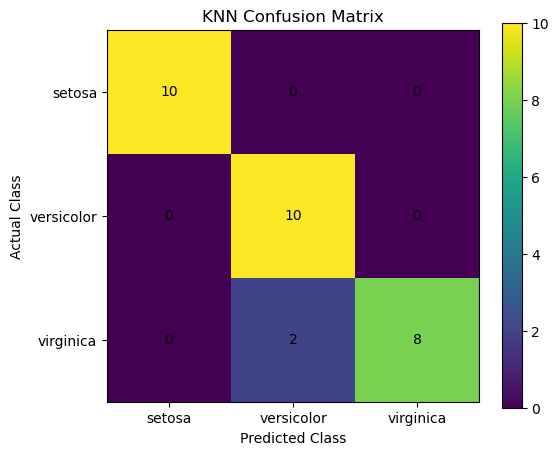

In [28]:
plt.figure(figsize=(6, 5))

plt.imshow(knn_cm)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    range(len(y.unique())),
    y.unique()
)

plt.yticks(
    range(len(y.unique())),
    y.unique()
)

for i in range(knn_cm.shape[0]):
    for j in range(knn_cm.shape[1]):
        plt.text(j, i, knn_cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

## KNN Hyperparameter Analysis

### Effect of K on Accuracy

In [30]:
k_values = range(1, 21)
k_accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)

    predictions = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, predictions)
    k_accuracies.append(accuracy)

best_k = k_values[np.argmax(k_accuracies)]
best_accuracy = max(k_accuracies)

print("Best K:", best_k)
print("Best Accuracy:", round(best_accuracy * 100, 2), "%")

Best K: 1
Best Accuracy: 96.67 %


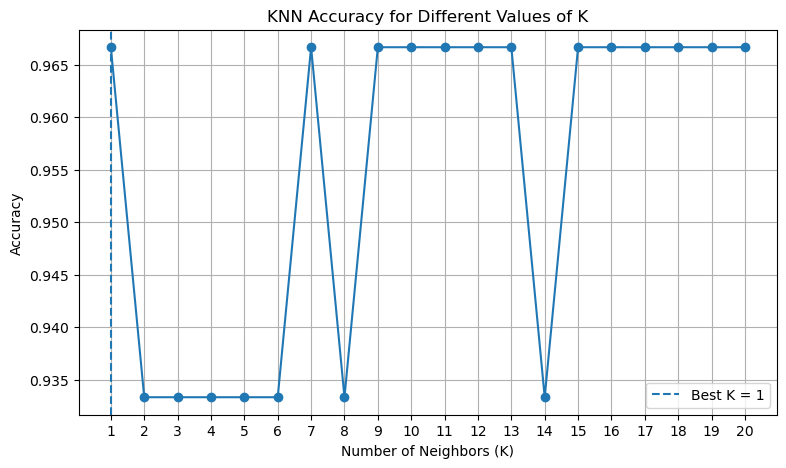

In [31]:
plt.figure(figsize=(9, 5))

plt.plot(
    list(k_values),
    k_accuracies,
    marker="o"
)

plt.axvline(
    best_k,
    linestyle="--",
    label=f"Best K = {best_k}"
)

plt.title("KNN Accuracy for Different Values of K")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.xticks(list(k_values))
plt.legend()
plt.grid()
plt.show()

## Best KNN Model

In [33]:
best_knn_model = KNeighborsClassifier(
    n_neighbors=best_k
)

best_knn_model.fit(
    X_train_scaled,
    y_train
)

y_pred_best_knn = best_knn_model.predict(
    X_test_scaled
)

best_knn_accuracy = accuracy_score(
    y_test,
    y_pred_best_knn
)

print("Best K:", best_k)
print("Best KNN Accuracy:", round(best_knn_accuracy * 100, 2), "%")

Best K: 1
Best KNN Accuracy: 96.67 %


## Model Performance Comparison

In [35]:
comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "KNN (K=5)",
        f"KNN (Best K={best_k})"
    ],
    "Accuracy": [
        dt_accuracy,
        knn_accuracy,
        best_knn_accuracy
    ],
    "Precision": [
        dt_precision,
        knn_precision,
        precision_score(
            y_test,
            y_pred_best_knn,
            average="weighted"
        )
    ],
    "Recall": [
        dt_recall,
        knn_recall,
        recall_score(
            y_test,
            y_pred_best_knn,
            average="weighted"
        )
    ],
    "F1-Score": [
        dt_f1,
        knn_f1,
        f1_score(
            y_test,
            y_pred_best_knn,
            average="weighted"
        )
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.933333,0.933333,0.933333,0.933333
1,KNN (K=5),0.933333,0.944444,0.933333,0.932660
2,KNN (Best K=1),0.966667,0.969697,0.966667,0.966583


In [36]:
comparison_percentage = comparison.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

comparison_percentage[metric_columns] = (
    comparison_percentage[metric_columns] * 100
)

comparison_percentage

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,93.333333,93.333333,93.333333,93.333333
1,KNN (K=5),93.333333,94.444444,93.333333,93.265993
2,KNN (Best K=1),96.666667,96.969697,96.666667,96.658312


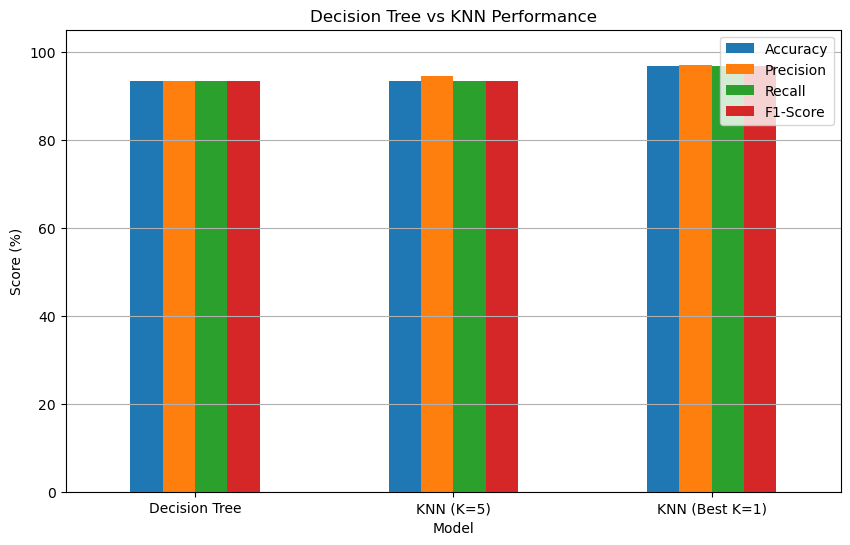

In [37]:
comparison_percentage.set_index("Model")[metric_columns].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Decision Tree vs KNN Performance")
plt.xlabel("Model")
plt.ylabel("Score (%)")
plt.xticks(rotation=0)
plt.ylim(0, 105)
plt.legend()
plt.grid(axis="y")
plt.show()

## Final Model Selection

In [39]:
best_model_index = comparison["Accuracy"].idxmax()

print(
    "Best Performing Model:",
    comparison.loc[best_model_index, "Model"]
)

print(
    "Accuracy:",
    round(
        comparison.loc[best_model_index, "Accuracy"] * 100,
        2
    ),
    "%"
)

Best Performing Model: KNN (Best K=1)
Accuracy: 96.67 %


## Conclusion

Decision Tree and K-Nearest Neighbour algorithms were successfully implemented on the Iris dataset. The dataset was divided into training and testing sets, and feature scaling was applied for KNN.

The Decision Tree classifier classified the Iris species using entropy-based recursive splitting and its feature importance was analyzed. KNN classified samples using distance-based voting after standardization of the features.

The effect of different values of K was also analyzed to identify the best K for KNN. Finally, the Decision Tree and KNN models were compared using Accuracy, Precision, Recall, and F1-Score.

The experiment demonstrates that both algorithms can effectively perform classification on the Iris dataset, while their performance depends on model-specific factors such as tree complexity and the choice of K and feature scaling in KNN.